<a href="https://colab.research.google.com/github/Eswa2020/urban-parking-prediction-models/blob/master/notebooks/Melbourne/02_parking_system_baseline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Importing libraries and loading dataset

In [ ]:
#importimg our libraries to use
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from datetime import datetime
%matplotlib inline

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

In [ ]:
#let's load the  dataset
dataq=pd.read_csv("/content/drive/MyDrive/melbourne_parking_data.csv",encoding='ISO-8859-1')
dataq.head(2)

,DeviceId,ArrivalTime,DepartureTime,DurationMinutes,StreetMarker,SignPlateID,Sign,AreaName,StreetId,StreetName,BetweenStreet1ID,BetweenStreet1,BetweenStreet2ID,BetweenStreet2,SideOfStreet,SideOfStreetCode,SideName,BayId,InViolation,VehiclePresent
0,17176,02/15/2019 07:45:29 PM,02/15/2019 07:46:52 PM,1,13009S,NaN,NaN,Docklands,528,COLLINS STREET,1285,SPENCER STREET,79,BATMANS HILL DRIVE,4,S,South,6005,False,True
1,17176,03/25/2019 08:35:40 PM,03/25/2019 08:39:08 PM,4,13009S,NaN,NaN,Docklands,528,COLLINS STREET,1285,SPENCER STREET,79,BATMANS HILL DRIVE,4,S,South,6005,False,True


In [ ]:
dataq.tail(2)

,DeviceId,ArrivalTime,DepartureTime,DurationMinutes,StreetMarker,SignPlateID,Sign,AreaName,StreetId,StreetName,BetweenStreet1ID,BetweenStreet1,BetweenStreet2ID,BetweenStreet2,SideOfStreet,SideOfStreetCode,SideName,BayId,InViolation,VehiclePresent
1048573,17418,05/15/2019 04:31:54 PM,05/15/2019 04:32:56 PM,1,13397W,430.0,1/4P M-F 16:00-18:30,Docklands,1383,VILLAGE STREET,131,BRENTANI WAY,974,MCCRAE STREET,5,W,West,6320,False,False
1048574,17418,05/25/2019 06:10:25 PM,05/25/2019 06:18:14 PM,8,13397W,362.0,1P SAT-SUN 7:30-18:30,Docklands,1383,VILLAGE STREET,131,BRENTANI WAY,974,MCCRAE STREET,5,W,West,6320,False,True


our dataset parking sensor data for year 2019.It is seems to be from Docklands ,Melbourne in australia.

## Exploring our dataset

In [ ]:
#We have about 1,048 ,575 rows and 20 columns.
# The dataset contains over 1.04 million valid parking records, which is large enough for robust temporal and operational analysis.
dataq.shape

(1048575, 20)

In [ ]:
#We check if we have any null values in our columns
#sign plate has like 20% which is expected behaviour
dataq.isna().sum()

,0
DeviceId,0
ArrivalTime,0
DepartureTime,0
DurationMinutes,0
StreetMarker,0
SignPlateID,286382
Sign,286382
AreaName,1
StreetId,0
StreetName,0


In [ ]:
#W have like 407 duplicates...should recheck thsi
dataq.duplicated().sum()

np.int64(407)

In [ ]:
#We have several interger columns none seems to be out of place
#we have 2 categorical(and also potential target variables "vehicle present and Inviolation")
dataq.dtypes


,0
DeviceId,int64
ArrivalTime,object
DepartureTime,object
DurationMinutes,int64
StreetMarker,object
SignPlateID,float64
Sign,object
AreaName,object
StreetId,int64
StreetName,object


In [ ]:
#WE have 8 columns that are intergers
descriptive_stats = dataq.describe()
print(descriptive_stats)

           DeviceId  DurationMinutes    SignPlateID      StreetId  \
count  1.048575e+06     1.048575e+06  762193.000000  1.048575e+06   
mean   1.731886e+04     4.799476e+01     285.859107  5.186585e+02   
std    2.998304e+02     9.260124e+01     158.747030  3.813933e+02   
min    1.003600e+04     0.000000e+00       3.000000  5.000000e+00   
25%    1.725800e+04     3.000000e+00     196.000000  1.230000e+02   
50%    1.731300e+04     1.200000e+01     285.000000  5.280000e+02   
75%    1.736800e+04     4.600000e+01     421.000000  7.530000e+02   
max    2.842100e+04     1.440000e+03     715.000000  1.497000e+03   

       BetweenStreet1ID  BetweenStreet2ID  SideOfStreet         BayId  
count      1.048575e+06      1.048575e+06  1.048575e+06  1.048575e+06  
mean       6.465055e+02      6.902358e+02  3.344938e+00  6.236924e+03  
std        4.197601e+02      5.153619e+02  1.092222e+00  2.275697e+02  
min        5.000000e+00      5.000000e+00  1.000000e+00  5.690000e+02  
25%        1.23000

In [ ]:
# DurationMinutes has a mean of about 48 minutes, indicating that the average parking event lasts less than one hour.
# The median duration is 12 minutes, which is much lower than the mean and suggests a strongly right-skewed distribution.
# The standard deviation of about 92.6 minutes shows substantial variation in parking duration across events.
# The minimum duration is 0 minutes, which may reflect very short stays, sensor noise, or recording artefacts.
# The 25th percentile is 3 minutes, meaning that a quarter of all parking events are extremely short.
# The 75th percentile is 46 minutes, meaning that most parking events are under one hour in duration.
# The maximum duration is 1,440 minutes, indicating the presence of very long stays or potential outliers in the dataset.

In [ ]:
descriptive_stats .to_csv('results.csv', index=False)

In [ ]:
correlation = descriptive_stats.corr()
correlation

,DeviceId,DurationMinutes,SignPlateID,StreetId,BetweenStreet1ID,BetweenStreet2ID,SideOfStreet,BayId
DeviceId,1.000000,0.999782,0.999777,0.999782,0.999781,0.999780,0.999764,0.999895
DurationMinutes,0.999782,1.000000,1.000000,1.000000,1.000000,0.999999,0.999999,0.999972
SignPlateID,0.999777,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.999972
StreetId,0.999782,1.000000,1.000000,1.000000,1.000000,1.000000,0.999999,0.999973
BetweenStreet1ID,0.999781,1.000000,1.000000,1.000000,1.000000,1.000000,0.999999,0.999973
BetweenStreet2ID,0.999780,0.999999,1.000000,1.000000,1.000000,1.000000,0.999999,0.999973
SideOfStreet,0.999764,0.999999,1.000000,0.999999,0.999999,0.999999,1.000000,0.999967
BayId,0.999895,0.999972,0.999972,0.999973,0.999973,0.999973,0.999967,1.000000


In [ ]:
# VehiclePresent frequency shows how often bays are recorded as occupied versus unoccupied in the dataset.
# InViolation frequency shows how often parking events are recorded as violating parking rules.
# These distributions help assess class balance before any classification or operational analysis.

vehicle_status_freq = dataq['VehiclePresent'].value_counts()
in_violation_freq = dataq['InViolation'].value_counts()

print("Vehicle Presence Frequency:")
print(vehicle_status_freq)

print("\nIn Violation Frequency:")
print(in_violation_freq)

Vehicle Presence Frequency:
VehiclePresent
True     537207
False    511368
Name: count, dtype: int64

In Violation Frequency:
InViolation
False    993420
True      55155
Name: count, dtype: int64


In [ ]:
# VehiclePresent is fairly balanced, with 537,207 True values and 511,368 False values, indicating a near-even split between occupied and unoccupied observations.
# InViolation is strongly skewed toward non-violations, with 993,420 False values versus 55,155 True values, indicating that parking violations are relatively rare events in the dataset.


##Cleaning Data

In [ ]:
# Data cleaning prepares the raw parking records for reliable analysis and modeling.
# This step removes duplicates, fixes datetime fields, checks missing values, and standardizes key variables.

In [ ]:
# Create a working copy to avoid changing the original dataset.
df = dataq.copy()


In [ ]:
# Check dataset shape before cleaning.
print("Initial shape:", df.shape)

Initial shape: (1048575, 20)


In [ ]:
# Remove duplicate records to avoid repeated parking events influencing the analysis.
df = df.drop_duplicates()

In [ ]:
# Convert datetime columns into proper datetime format for time-based analysis.
df["ArrivalTime"] = pd.to_datetime(df["ArrivalTime"], errors="coerce")
df["DepartureTime"] = pd.to_datetime(df["DepartureTime"], errors="coerce")

/tmp/ipykernel_2247/2302069356.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["ArrivalTime"] = pd.to_datetime(df["ArrivalTime"], errors="coerce")
/tmp/ipykernel_2247/2302069356.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["DepartureTime"] = pd.to_datetime(df["DepartureTime"], errors="coerce")


In [ ]:
# Check missing values in the main variables used for analysis.
missing_summary = df[[
    "ArrivalTime", "DepartureTime", "DurationMinutes",
    "AreaName", "StreetName", "BayId", "VehiclePresent", "InViolation"
]].isnull().sum()

print("\nMissing values in key columns:")
print(missing_summary)


Missing values in key columns:
ArrivalTime        0
DepartureTime      0
DurationMinutes    0
AreaName           1
StreetName         0
BayId              0
VehiclePresent     0
InViolation        0
dtype: int64


In [ ]:
# Drop rows with missing values in essential analytical fields.
df = df.dropna(subset=[
    "ArrivalTime", "DepartureTime", "DurationMinutes",
    "AreaName", "BayId", "VehiclePresent", "InViolation"
])

In [ ]:
# Keep only non-negative durations because negative parking time is not valid.
df = df[df["DurationMinutes"] >= 0]

In [ ]:
# Convert boolean status fields into integer form for easier aggregation and modeling.
df["VehiclePresent"] = df["VehiclePresent"].astype(int)
df["InViolation"] = df["InViolation"].astype(int)

In [ ]:
# Check dataset shape after cleaning.
print("\nCleaned shape:", df.shape)

# Display data types after cleaning.
print("\nData types after cleaning:")
print(df.dtypes)



Cleaned shape: (1048167, 20)

Data types after cleaning:
DeviceId                     int64
ArrivalTime         datetime64[ns]
DepartureTime       datetime64[ns]
DurationMinutes              int64
StreetMarker                object
SignPlateID                float64
Sign                        object
AreaName                    object
StreetId                     int64
StreetName                  object
BetweenStreet1ID             int64
BetweenStreet1              object
BetweenStreet2ID             int64
BetweenStreet2              object
SideOfStreet                 int64
SideOfStreetCode            object
SideName                    object
BayId                        int64
InViolation                  int64
VehiclePresent               int64
dtype: object


In [ ]:
# Preview the cleaned dataset.
df.head(2)

,DeviceId,ArrivalTime,DepartureTime,DurationMinutes,StreetMarker,SignPlateID,Sign,AreaName,StreetId,StreetName,BetweenStreet1ID,BetweenStreet1,BetweenStreet2ID,BetweenStreet2,SideOfStreet,SideOfStreetCode,SideName,BayId,InViolation,VehiclePresent
0,17176,2019-02-15 19:45:29,2019-02-15 19:46:52,1,13009S,NaN,NaN,Docklands,528,COLLINS STREET,1285,SPENCER STREET,79,BATMANS HILL DRIVE,4,S,South,6005,0,1
1,17176,2019-03-25 20:35:40,2019-03-25 20:39:08,4,13009S,NaN,NaN,Docklands,528,COLLINS STREET,1285,SPENCER STREET,79,BATMANS HILL DRIVE,4,S,South,6005,0,1


##Feature Enginnering

In [ ]:
# Exploratory data analysis is used to understand the distribution, timing, and operational patterns of parking activity.
# This step helps identify skewness, temporal trends, class balance, and area-level variation before modeling.

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Create core temporal features for exploratory analysis.
df["date"] = df["ArrivalTime"].dt.date
df["month"] = df["ArrivalTime"].dt.month
df["day_of_week"] = df["ArrivalTime"].dt.day_name()
df["arrival_hour"] = df["ArrivalTime"].dt.hour


In [ ]:
# Create a weekday/weekend variable for clearer operational comparison.
df["day_type"] = np.where(df["ArrivalTime"].dt.dayofweek >= 5, "Weekend", "Weekday")

In [ ]:
# Create a season variable using Australian seasonal grouping.
def get_season(month):
    if month in [12, 1, 2]:
        return "Summer"
    elif month in [3, 4, 5]:
        return "Autumn"
    elif month in [6, 7, 8]:
        return "Winter"
    else:
        return "Spring"

df["season"] = df["month"].apply(get_season)

##EDA

In [ ]:
# Summary statistics for duration.
print("Duration summary:")
print(df["DurationMinutes"].describe())


Duration summary:
count    1.048167e+06
mean     4.801154e+01
std      9.260531e+01
min      0.000000e+00
25%      3.000000e+00
50%      1.200000e+01
75%      4.600000e+01
max      1.440000e+03
Name: DurationMinutes, dtype: float64


In [ ]:
# Frequency of occupancy and violation variables.
print("\nVehicle presence frequency:")
print(df["VehiclePresent"].value_counts())

print("\nViolation frequency:")
print(df["InViolation"].value_counts())



Vehicle presence frequency:
VehiclePresent
1    536856
0    511311
Name: count, dtype: int64

Violation frequency:
InViolation
0    993012
1     55155
Name: count, dtype: int64


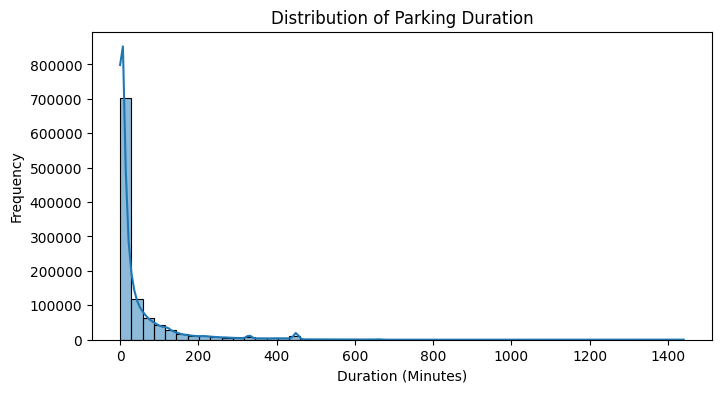

In [ ]:
# Plot the distribution of parking duration.
plt.figure(figsize=(8, 4))
sns.histplot(df["DurationMinutes"], bins=50, kde=True)
plt.title("Distribution of Parking Duration")
plt.xlabel("Duration (Minutes)")
plt.ylabel("Frequency")
plt.show()

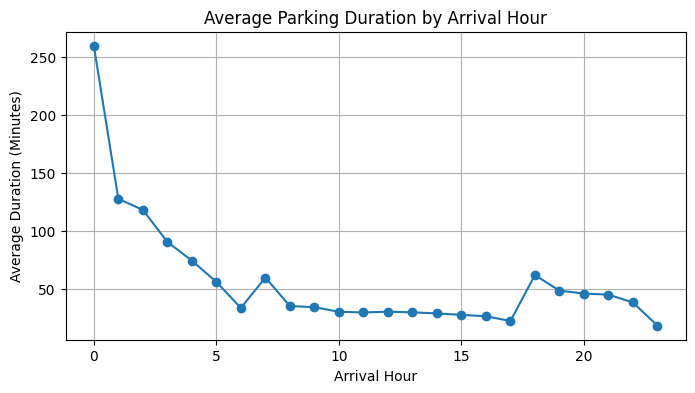

In [ ]:
# Plot average duration by hour of arrival.
hourly_duration = df.groupby("arrival_hour")["DurationMinutes"].mean()

plt.figure(figsize=(8, 4))
hourly_duration.plot(marker="o")
plt.title("Average Parking Duration by Arrival Hour")
plt.xlabel("Arrival Hour")
plt.ylabel("Average Duration (Minutes)")
plt.grid(True)
plt.show()

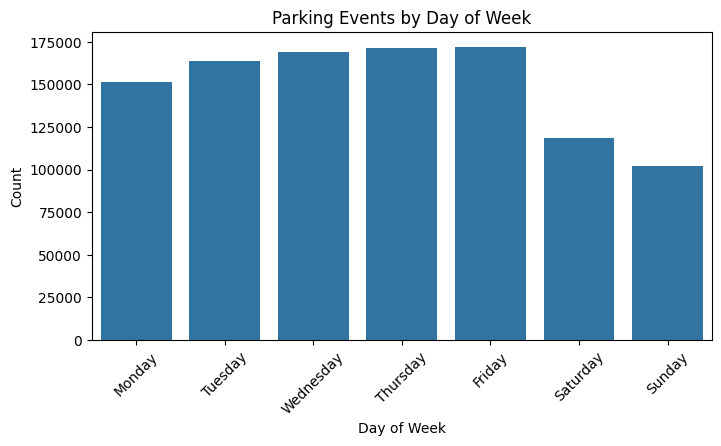

In [ ]:
# Plot number of parking events by day of week.
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

plt.figure(figsize=(8, 4))
sns.countplot(data=df, x="day_of_week", order=day_order)
plt.title("Parking Events by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

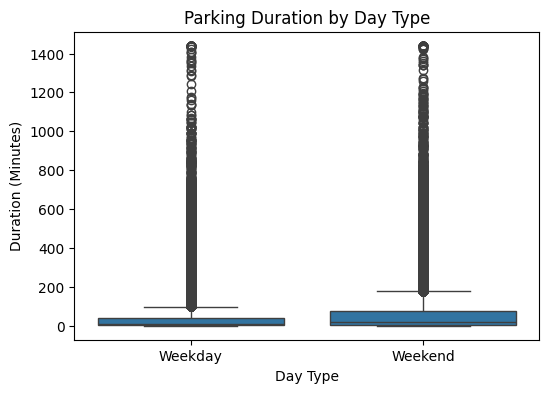

In [ ]:
# Plot average duration by day type.
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x="day_type", y="DurationMinutes")
plt.title("Parking Duration by Day Type")
plt.xlabel("Day Type")
plt.ylabel("Duration (Minutes)")
plt.show()

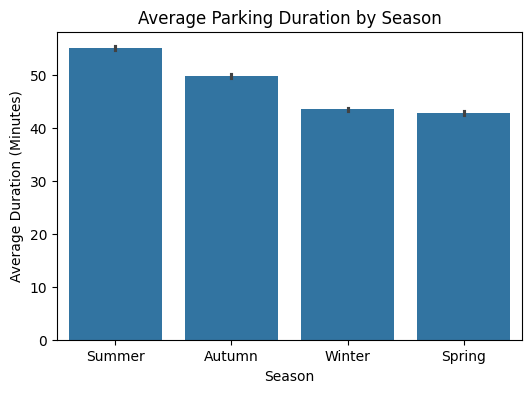

In [ ]:
# Plot average parking duration by season.
plt.figure(figsize=(6, 4))
sns.barplot(data=df, x="season", y="DurationMinutes", order=["Summer", "Autumn", "Winter", "Spring"])
plt.title("Average Parking Duration by Season")
plt.xlabel("Season")
plt.ylabel("Average Duration (Minutes)")
plt.show()

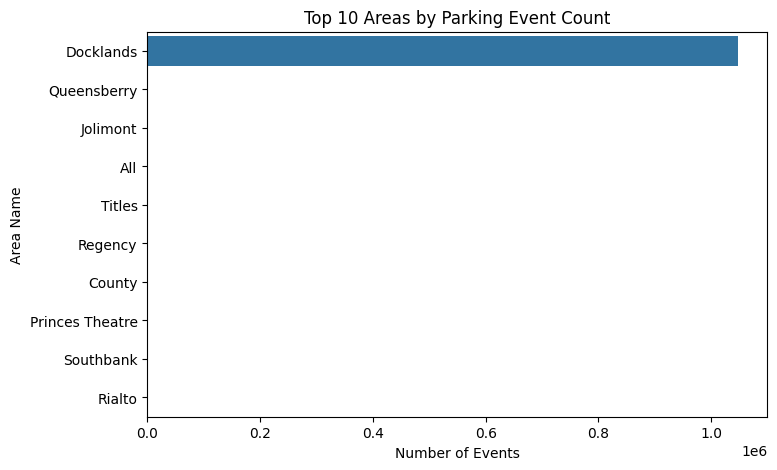

In [ ]:
# Identify the top 10 areas by number of parking events.
top_areas = df["AreaName"].value_counts().head(10)

plt.figure(figsize=(8, 5))
sns.barplot(x=top_areas.values, y=top_areas.index)
plt.title("Top 10 Areas by Parking Event Count")
plt.xlabel("Number of Events")
plt.ylabel("Area Name")
plt.show()

## Spatial Analysis

In [ ]:
# Spatial summary analysis is used to identify which areas and streets dominate parking activity, duration, and violations before moving to formal modeling.

In [ ]:
# Area-level parking activity
area_summary = df.groupby("AreaName").agg(
    total_events=("BayId", "count"),
    mean_duration=("DurationMinutes", "mean"),
    occupancy_rate=("VehiclePresent", "mean"),
    violation_rate=("InViolation", "mean")
).sort_values("total_events", ascending=False)

area_summary.head(10)

,total_events,mean_duration,occupancy_rate,violation_rate
AreaName,,,,
Docklands,1046965,48.007337,0.512187,0.052652
Queensberry,116,87.068966,0.448276,0.008621
Jolimont,72,62.166667,0.444444,0.027778
All,67,74.179104,0.462687,0.059701
Titles,64,48.875000,0.515625,0.046875
Regency,59,42.694915,0.440678,0.000000
County,55,27.218182,0.600000,0.036364
Princes Theatre,53,38.792453,0.547170,0.000000
Southbank,52,97.096154,0.403846,0.000000


In [ ]:
# Street-level parking activity
street_summary = df.groupby("StreetName").agg(
    total_events=("BayId", "count"),
    mean_duration=("DurationMinutes", "mean"),
    occupancy_rate=("VehiclePresent", "mean"),
    violation_rate=("InViolation", "mean")
).sort_values("total_events", ascending=False)

street_summary.head(10)

,total_events,mean_duration,occupancy_rate,violation_rate
StreetName,,,,
BOURKE STREET,295866,45.224551,0.510525,0.046812
HARBOUR ESPLANADE,249469,56.803102,0.504953,0.045753
COLLINS STREET,169395,40.626518,0.516231,0.052186
BATMANS HILL DRIVE,114214,46.612963,0.512301,0.052647
MERCHANT STREET,67976,43.811728,0.508827,0.012622
LA TROBE STREET,38013,39.732013,0.509536,0.107805
SEAFARER LANE,37861,30.360714,0.518211,0.078445
VILLAGE STREET,23198,56.634020,0.532934,0.123114
MCCRAE STREET,19873,50.664822,0.552357,0.131485


In [ ]:
# Compare Docklands with other areas
docklands_vs_rest = df.assign(
    docklands_flag=np.where(df["AreaName"].str.contains("Docklands", case=False, na=False), "Docklands", "Other Areas")
).groupby("docklands_flag").agg(
    total_events=("BayId", "count"),
    mean_duration=("DurationMinutes", "mean"),
    occupancy_rate=("VehiclePresent", "mean"),
    violation_rate=("InViolation", "mean")
)

docklands_vs_rest

,total_events,mean_duration,occupancy_rate,violation_rate
docklands_flag,,,,
Docklands,1046965,48.007337,0.512187,0.052652
Other Areas,1202,51.672213,0.510815,0.024958


In [ ]:
#dataset is overwhelmingly Docklands-centered, with about 1,046,965 records from Docklands versus only about 1,202 from all other areas combined.
#Street activity is also concentrated on a small set of streets, especially Bourke Street, Harbour Esplanade, Collins Street, and Batmans Hill Drive. #Occupancy rates are fairly similar between Docklands and the rest, but Docklands has a noticeably higher violation rate.
#That means the project should be framed as a Docklands-dominant Melbourne parking dynamics study, not a fully citywide Melbourne study.

#Forecasting Layer

In [ ]:
# Forecasting is used to estimate short-term parking dynamics over time using aggregated street-hour operational patterns.

In [ ]:
#restricted forecasting analysis to the dominant study area to avoid weak signals from very small peripheral groups.
docklands_df = df[df["AreaName"].str.contains("Docklands", case=False, na=False)].copy()

In [ ]:
# Created a full datetime hour variable for time-based aggregation.
docklands_df["arrival_hour_ts"] = docklands_df["ArrivalTime"].dt.floor("H")

/tmp/ipykernel_2247/3235687266.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  docklands_df["arrival_hour_ts"] = docklands_df["ArrivalTime"].dt.floor("H")


In [ ]:
# Aggregated parking activity by street and hour.
street_hour = (
    docklands_df.groupby(["StreetName", "arrival_hour_ts"], as_index=False)
    .agg(
        occupancy_rate=("VehiclePresent", "mean"),
        mean_duration=("DurationMinutes", "mean"),
        event_count=("BayId", "count"),
        violation_rate=("InViolation", "mean")
    )
    .sort_values(["StreetName", "arrival_hour_ts"])
)

print(street_hour.shape)
street_hour.head()

(78179, 6)


,StreetName,arrival_hour_ts,occupancy_rate,mean_duration,event_count,violation_rate
0,AQUITANIA WAY,2019-04-11 08:00:00,1.000,20.000000,1,0.0
1,AQUITANIA WAY,2019-08-02 16:00:00,0.000,1.000000,1,0.0
2,AQUITANIA WAY,2019-09-30 17:00:00,1.000,0.000000,1,0.0
3,AURORA LANE,2019-08-13 12:00:00,1.000,3.000000,1,0.0
4,BATMANS HILL DRIVE,2019-01-01 00:00:00,0.625,149.208333,24,0.0


In [ ]:
#created Lag features

In [ ]:
# Lag features capture short-run temporal dependence in parking activity.
street_hour = street_hour.sort_values(["StreetName", "arrival_hour_ts"]).copy()

street_hour["lag_1_occ"] = street_hour.groupby("StreetName")["occupancy_rate"].shift(1)
street_hour["lag_2_occ"] = street_hour.groupby("StreetName")["occupancy_rate"].shift(2)
street_hour["lag_24_occ"] = street_hour.groupby("StreetName")["occupancy_rate"].shift(24)

street_hour["hour"] = street_hour["arrival_hour_ts"].dt.hour
street_hour["day_of_week"] = street_hour["arrival_hour_ts"].dt.dayofweek
street_hour["month"] = street_hour["arrival_hour_ts"].dt.month

street_hour = street_hour.dropna().copy()

print(street_hour.shape)
street_hour.head()

(77847, 12)


,StreetName,arrival_hour_ts,occupancy_rate,mean_duration,event_count,violation_rate,lag_1_occ,lag_2_occ,lag_24_occ,hour,day_of_week,month
28,BATMANS HILL DRIVE,2019-01-02 02:00:00,1.000000,305.000000,1,0.0,0.500000,0.076923,0.625,2,2,1
29,BATMANS HILL DRIVE,2019-01-02 03:00:00,0.500000,64.000000,2,0.0,1.000000,0.500000,0.375,3,2,1
30,BATMANS HILL DRIVE,2019-01-02 04:00:00,1.000000,26.000000,1,0.0,0.500000,1.000000,0.500,4,2,1
31,BATMANS HILL DRIVE,2019-01-02 05:00:00,0.555556,49.000000,9,0.0,1.000000,0.500000,0.000,5,2,1
32,BATMANS HILL DRIVE,2019-01-02 06:00:00,0.571429,35.714286,7,0.0,0.555556,1.000000,0.500,6,2,1


#Forecasting Model Comparison

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor

# Select features for forecasting occupancy rate.
X = street_hour[["lag_1_occ", "lag_2_occ", "lag_24_occ", "hour", "day_of_week", "month"]]
y = street_hour["occupancy_rate"]

In [ ]:
# Use a time-ordered split instead of random shuffling.
split_index = int(len(street_hour) * 0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

In [ ]:
# Naive baseline using previous-hour occupancy.
baseline_pred = X_test["lag_1_occ"]

baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = mean_squared_error(y_test, baseline_pred) ** 0.5

In [ ]:
# Random Forest forecasting model.
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = mean_squared_error(y_test, rf_pred) ** 0.5

print("Baseline MAE:", baseline_mae)
print("Baseline RMSE:", baseline_rmse)
print("RF MAE:", rf_mae)
print("RF RMSE:", rf_rmse)

Baseline MAE: 0.2822931563203458
Baseline RMSE: 0.40105788299538864
RF MAE: 0.17355933561600279
RF RMSE: 0.24656356492962694


In [ ]:
## The Random Forest forecasting model substantially improves on the naive baseline, indicating that lagged occupancy and temporal features contain useful predictive signal for Docklands street-hour parking dynamics.

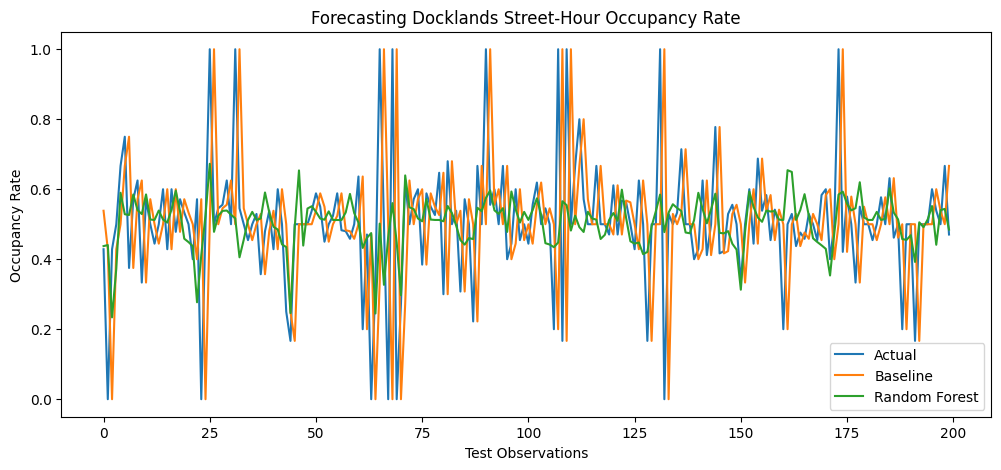

In [ ]:
import matplotlib.pyplot as plt

# Compare actual and predicted occupancy rates for a short test window.
plot_df = pd.DataFrame({
    "actual": y_test.values[:200],
    "baseline": baseline_pred.values[:200],
    "rf_pred": rf_pred[:200]
})

plt.figure(figsize=(12, 5))
plt.plot(plot_df["actual"], label="Actual")
plt.plot(plot_df["baseline"], label="Baseline")
plt.plot(plot_df["rf_pred"], label="Random Forest")
plt.title("Forecasting Docklands Street-Hour Occupancy Rate")
plt.xlabel("Test Observations")
plt.ylabel("Occupancy Rate")
plt.legend()
plt.show()

In [ ]:
#the baseline tracks the sharp spikes and drops too literally because it just copies the last observed hour, while the Random Forest is smoother and closer to the central occupancy pattern. So the baseline overreacts to volatility, whereas the RF generalizes better.

#Multi-Variate Regression Layer

In [ ]:
# Multivariate regression is used to explain variation in parking duration using temporal, operational, and spatial features.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

In [ ]:
# Create a modeling dataset for duration analysis.
reg_df = docklands_df.copy()

In [ ]:
# Keep essential variables.
reg_df = reg_df[[
    "DurationMinutes", "arrival_hour", "day_of_week", "day_type",
    "season", "StreetName", "BayId", "InViolation", "VehiclePresent"
]].dropna().copy()

In [ ]:
# Define target and predictors.
X = reg_df.drop(columns=["DurationMinutes"])
y = reg_df["DurationMinutes"]

In [ ]:
# Identify numeric and categorical columns.
numeric_features = ["arrival_hour", "BayId", "InViolation", "VehiclePresent"]
categorical_features = ["day_of_week", "day_type", "season", "StreetName"]

In [ ]:
# Preprocessing for mixed data types.
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [ ]:
# Time-aware split using row order after sorting by arrival time.
reg_df = docklands_df.sort_values("ArrivalTime").copy()
reg_df = reg_df[[
    "DurationMinutes", "arrival_hour", "day_of_week", "day_type",
    "season", "StreetName", "BayId", "InViolation", "VehiclePresent"
]].dropna().copy()

X = reg_df.drop(columns=["DurationMinutes"])
y = reg_df["DurationMinutes"]

split_index = int(len(reg_df) * 0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

In [ ]:
# Linear regression pipeline.
lr_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = mean_squared_error(y_test, lr_pred) ** 0.5
lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression MAE:", lr_mae)
print("Linear Regression RMSE:", lr_rmse)
print("Linear Regression R²:", lr_r2)

Linear Regression MAE: 51.035206319452314
Linear Regression RMSE: 81.00813849857056
Linear Regression R²: 0.13296505604682818


In [ ]:
# Random Forest regression pipeline.
rf_reg_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=100,
        max_depth=12,
        random_state=42,
        n_jobs=-1
    ))
])

rf_reg_model.fit(X_train, y_train)
rf_reg_pred = rf_reg_model.predict(X_test)

rf_reg_mae = mean_absolute_error(y_test, rf_reg_pred)
rf_reg_rmse = mean_squared_error(y_test, rf_reg_pred) ** 0.5
rf_reg_r2 = r2_score(y_test, rf_reg_pred)

print("Random Forest Regression MAE:", rf_reg_mae)
print("Random Forest Regression RMSE:", rf_reg_rmse)
print("Random Forest Regression R²:", rf_reg_r2)

Random Forest Regression MAE: 37.37441595125017
Random Forest Regression RMSE: 64.96195986027529
Random Forest Regression R²: 0.442432394249311


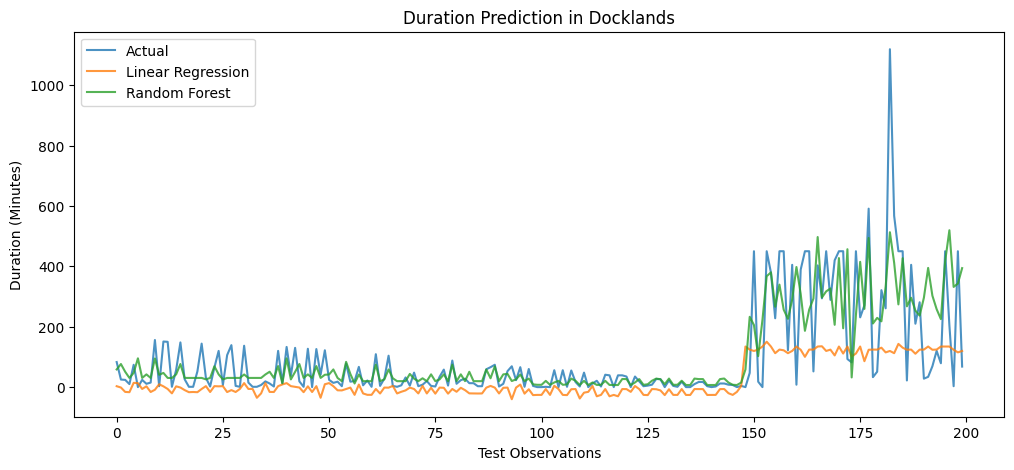

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Compare actual and predicted duration for a short test sample.
plot_reg = pd.DataFrame({
    "actual": y_test.values[:200],
    "linear_regression": lr_pred[:200],
    "random_forest": rf_reg_pred[:200]
})

plt.figure(figsize=(12, 5))
plt.plot(plot_reg["actual"], label="Actual", alpha=0.8)
plt.plot(plot_reg["linear_regression"], label="Linear Regression", alpha=0.8)
plt.plot(plot_reg["random_forest"], label="Random Forest", alpha=0.8)
plt.title("Duration Prediction in Docklands")
plt.xlabel("Test Observations")
plt.ylabel("Duration (Minutes)")
plt.legend()
plt.show()

In [ ]:
# The regression comparison evaluates whether parking duration is primarily linear and interpretable or better captured through nonlinear feature interactions.

In [ ]:
#the Random Forest regression model clearly outperforms linear regression, which suggests that parking duration in Docklands is influenced by nonlinear relationships and feature interactions that a simple linear model does not capture well.

In [ ]:
#Layer 1 showed that forecasting improves when you use lagged and temporal features instead of a naive persistence baseline.
#Layer 2 now shows that duration is better modeled with nonlinear methods than with a classical linear regression alone.

In [ ]:
# Street-level clustering groups Docklands streets into operational parking typologies that complement the predictive and prescriptive layers.

#Stochastic Modelling

In [ ]:
# Stochastic modeling is used to estimate how parking states transition over time within individual bays.

In [ ]:
# The Markov transition matrix shows whether parking states are persistent over time and whether occupancy behavior differs between weekdays and weekends.

In [ ]:
# Create a bay-level ordered dataset for Markov analysis.
markov_df = docklands_df[["BayId", "ArrivalTime", "VehiclePresent"]].dropna().copy()
markov_df = markov_df.sort_values(["BayId", "ArrivalTime"])

In [ ]:
# Define the current and next state within each bay.
markov_df["state"] = np.where(markov_df["VehiclePresent"] == 1, "occupied", "empty")
markov_df["next_state"] = markov_df.groupby("BayId")["state"].shift(-1)

In [ ]:
# Remove rows where the next state is missing.
markov_df = markov_df.dropna(subset=["next_state"]).copy()

print(markov_df.shape)
markov_df.head()

(1046761, 5)


,BayId,ArrivalTime,VehiclePresent,state,next_state
15076,6005,2019-01-01 00:00:00,1,occupied,empty
7781,6005,2019-01-01 01:17:00,0,empty,occupied
10106,6005,2019-01-01 01:29:00,1,occupied,empty
3038,6005,2019-01-01 01:39:00,0,empty,occupied
23134,6005,2019-01-01 02:17:00,1,occupied,empty


In [ ]:
#next we build the transition matrix

In [ ]:
# Calculate the Markov transition counts and probabilities.
transition_counts = pd.crosstab(markov_df["state"], markov_df["next_state"])
transition_probs = transition_counts.div(transition_counts.sum(axis=1), axis=0)

print("Transition Counts:")
print(transition_counts)

print("\nTransition Probabilities:")
print(transition_probs)

Transition Counts:
next_state   empty  occupied
state                       
empty        67400    443223
occupied    443269     92869

Transition Probabilities:
next_state     empty  occupied
state                         
empty       0.131996  0.868004
occupied    0.826782  0.173218


In [ ]:
#then estimate the steady-state distribution

In [ ]:
# Estimate the long-run steady-state distribution from the transition matrix.
P = transition_probs.values

eigvals, eigvecs = np.linalg.eig(P.T)
steady_state = np.real(eigvecs[:, np.isclose(eigvals, 1)])
steady_state = steady_state[:, 0]
steady_state = steady_state / steady_state.sum()

steady_state_df = pd.DataFrame({
    "state": transition_probs.index,
    "steady_state_probability": steady_state
})

print("Steady-State Distribution:")
print(steady_state_df)

Steady-State Distribution:
      state  steady_state_probability
0     empty                  0.487838
1  occupied                  0.512162


In [ ]:
#compare weekday versus weekend transitions:

In [ ]:
# Compare transition behavior between weekdays and weekends.
markov_daytype = docklands_df[["BayId", "ArrivalTime", "VehiclePresent", "day_type"]].dropna().copy()
markov_daytype = markov_daytype.sort_values(["BayId", "ArrivalTime"])

markov_daytype["state"] = np.where(markov_daytype["VehiclePresent"] == 1, "occupied", "empty")
markov_daytype["next_state"] = markov_daytype.groupby("BayId")["state"].shift(-1)
markov_daytype["next_day_type"] = markov_daytype.groupby("BayId")["day_type"].shift(-1)

markov_daytype = markov_daytype.dropna(subset=["next_state"]).copy()

for dt in ["Weekday", "Weekend"]:
    subset = markov_daytype[markov_daytype["day_type"] == dt]
    trans = pd.crosstab(subset["state"], subset["next_state"])
    trans_prob = trans.div(trans.sum(axis=1), axis=0)

    print(f"\nTransition Probabilities for {dt}:")
    print(trans_prob)


Transition Probabilities for Weekday:
next_state     empty  occupied
state                         
empty       0.124168  0.875832
occupied    0.830059  0.169941

Transition Probabilities for Weekend:
next_state     empty  occupied
state                         
empty       0.160994  0.839006
occupied    0.814378  0.185622


In [ ]:
#From empty:empty → empty = 0.1320
#empty → occupied = 0.8680

#From occupied:occupied → empty = 0.8268
#occupied → occupied = 0.1732

#Steady-state distribution:empty = 0.4878
#occupied = 0.5122

#Weekday:empty → occupied = 0.8758
#occupied → occupied = 0.1699

#Weekend:empty → occupied = 0.8390
#occupied → occupied = 0.1856

In [ ]:
#Interpretation:the chain flips state very often, which suggests the current event-level sequencing is capturing alternating parking events rather than a smoothly persistent bay-occupancy process. That does not make it useless, but it means the stochastic layer should be interpreted as event-transition behavior, not as a stable continuous occupancy-state process.

In [ ]:
## The Markov results indicate frequent switching between empty and occupied states, suggesting that the current event-level sequence reflects short-run parking turnover rather than long-run bay-state persistence.

In [ ]:
## Transition patterns are broadly similar across weekdays and weekends, although weekend occupancy appears slightly more persistent once a bay becomes occupied.

In [ ]:
#the event-level parking process in Docklands shows high turnover and frequent state switching, with a near-balanced long-run distribution between empty and occupied states.

#Prescriptive Analytics

In [ ]:
# Prescriptive analytics translates predicted parking conditions into simple operational recommendations for monitoring, enforcement, and parking management.

In [ ]:
#This layer should use outputs from the forecasting, regression, and stochastic analyses to assign a simple operational recommendation at street-hour level.

In [ ]:
# Build a street-hour recommendation table using forecasting and operational risk signals.
prescriptive_df = street_hour.copy()

In [ ]:
# Create a simple persistence signal from the Markov steady-state and turnover pattern.
# Since the Markov model shows frequent switching, we use it as a turnover indicator rather than a persistence score.
prescriptive_df["high_turnover_flag"] = np.where(
    (prescriptive_df["occupancy_rate"].between(0.4, 0.7)) & (prescriptive_df["event_count"] > prescriptive_df["event_count"].median()),
    1, 0
)

In [ ]:
# Define demand and risk thresholds.
high_occ_threshold = prescriptive_df["occupancy_rate"].quantile(0.75)
high_duration_threshold = prescriptive_df["mean_duration"].quantile(0.75)
high_violation_threshold = prescriptive_df["violation_rate"].quantile(0.75)

In [ ]:
# Create operational recommendation rules.
def assign_action(row):
    if row["occupancy_rate"] >= high_occ_threshold and row["violation_rate"] >= high_violation_threshold:
        return "Enforcement priority"
    elif row["occupancy_rate"] >= high_occ_threshold and row["mean_duration"] >= high_duration_threshold:
        return "Pricing or turnover review"
    elif row["high_turnover_flag"] == 1:
        return "Monitor high-turnover area"
    else:
        return "Routine monitoring"

prescriptive_df["recommended_action"] = prescriptive_df.apply(assign_action, axis=1)


In [ ]:
# Review the distribution of recommendations.
action_counts = prescriptive_df["recommended_action"].value_counts()
print(action_counts)

prescriptive_df.head()

recommended_action
Routine monitoring            36320
Monitor high-turnover area    30838
Enforcement priority           5995
Pricing or turnover review     4694
Name: count, dtype: int64


,StreetName,arrival_hour_ts,occupancy_rate,mean_duration,event_count,violation_rate,lag_1_occ,lag_2_occ,lag_24_occ,hour,day_of_week,month,high_turnover_flag,recommended_action
28,BATMANS HILL DRIVE,2019-01-02 02:00:00,1.000000,305.000000,1,0.0,0.500000,0.076923,0.625,2,2,1,0,Pricing or turnover review
29,BATMANS HILL DRIVE,2019-01-02 03:00:00,0.500000,64.000000,2,0.0,1.000000,0.500000,0.375,3,2,1,0,Routine monitoring
30,BATMANS HILL DRIVE,2019-01-02 04:00:00,1.000000,26.000000,1,0.0,0.500000,1.000000,0.500,4,2,1,0,Routine monitoring
31,BATMANS HILL DRIVE,2019-01-02 05:00:00,0.555556,49.000000,9,0.0,1.000000,0.500000,0.000,5,2,1,1,Monitor high-turnover area
32,BATMANS HILL DRIVE,2019-01-02 06:00:00,0.571429,35.714286,7,0.0,0.555556,1.000000,0.500,6,2,1,1,Monitor high-turnover area


In [ ]:
#summarized by street

In [ ]:
# Summarize recommendations at street level.
street_actions = (
    prescriptive_df.groupby(["StreetName", "recommended_action"])
    .size()
    .reset_index(name="count")
    .sort_values(["StreetName", "count"], ascending=[True, False])
)

street_actions.head(20)

,StreetName,recommended_action,count
1,BATMANS HILL DRIVE,Monitor high-turnover area,4496
3,BATMANS HILL DRIVE,Routine monitoring,2826
0,BATMANS HILL DRIVE,Enforcement priority,393
2,BATMANS HILL DRIVE,Pricing or turnover review,270
5,BOURKE STREET,Monitor high-turnover area,6466
7,BOURKE STREET,Routine monitoring,1716
6,BOURKE STREET,Pricing or turnover review,252
4,BOURKE STREET,Enforcement priority,171
11,BRENTANI WAY,Routine monitoring,3080
10,BRENTANI WAY,Pricing or turnover review,706


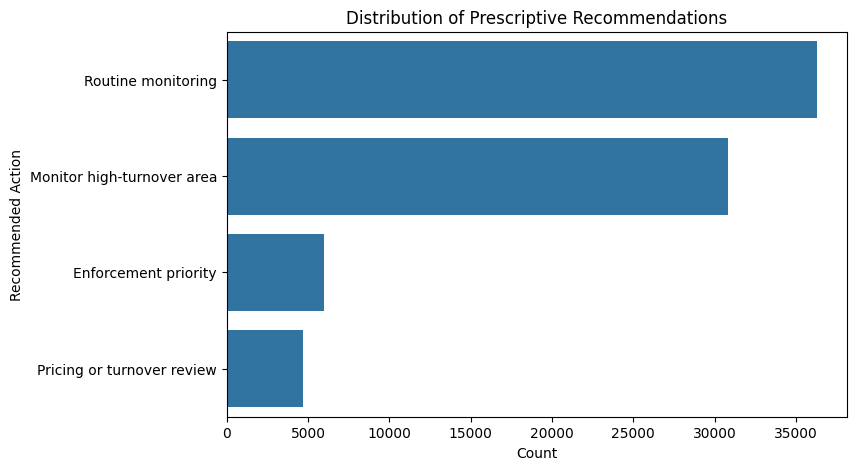

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.countplot(data=prescriptive_df, y="recommended_action", order=prescriptive_df["recommended_action"].value_counts().index)
plt.title("Distribution of Prescriptive Recommendations")
plt.xlabel("Count")
plt.ylabel("Recommended Action")
plt.show()

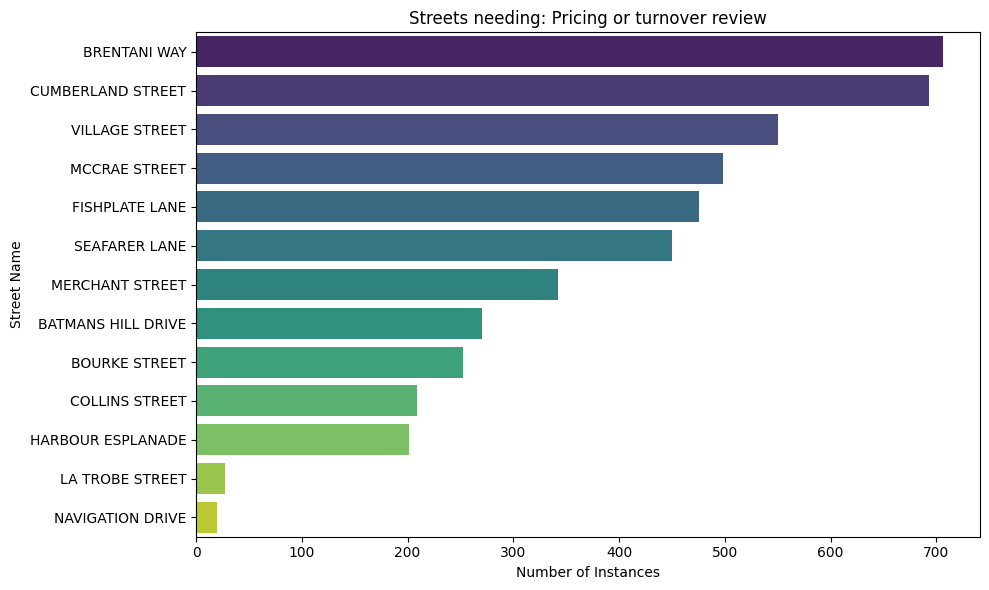

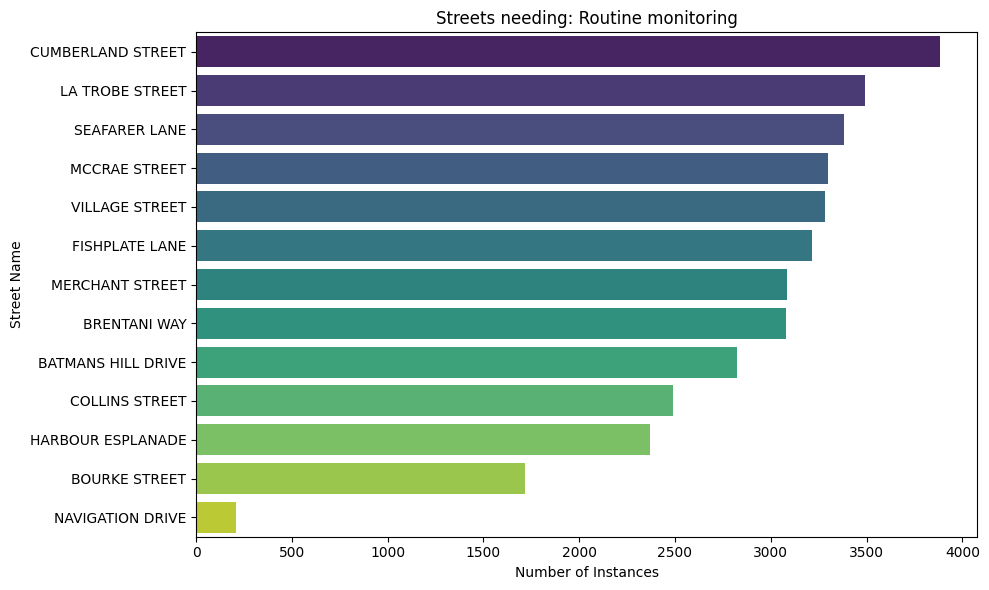

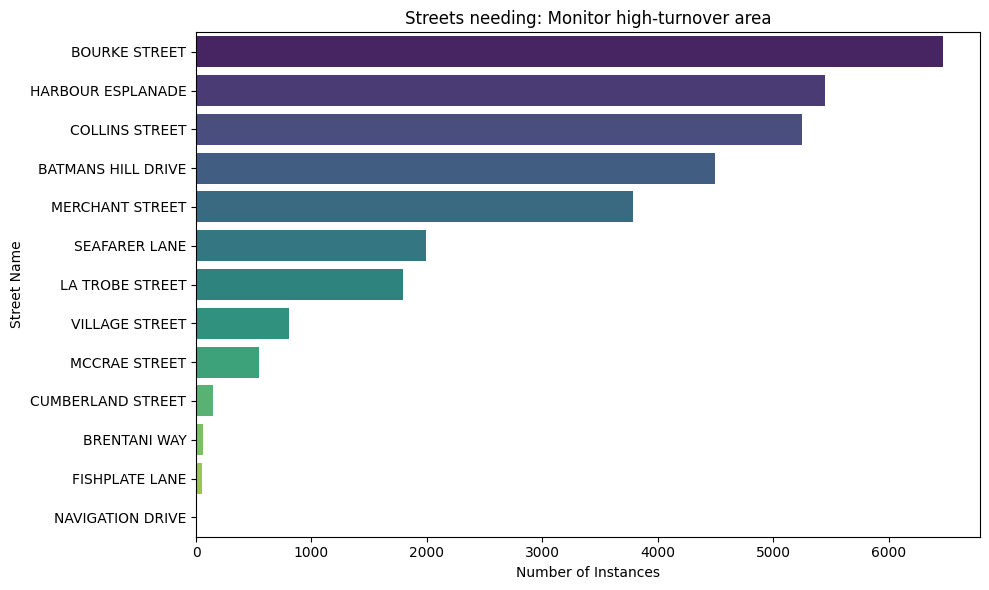

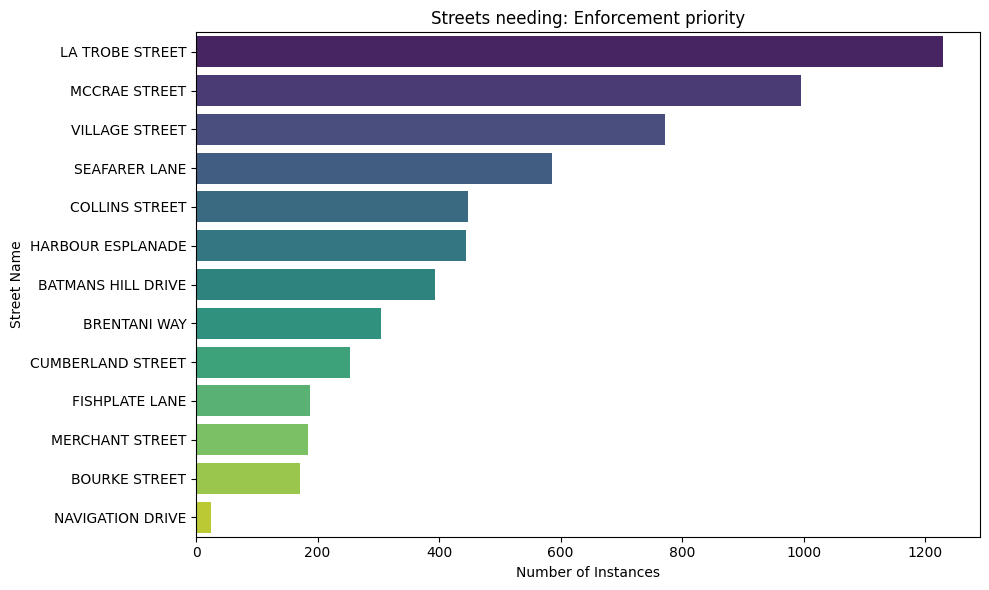

In [ ]:
for action_category in prescriptive_df['recommended_action'].unique():
    subset_data = street_actions[street_actions['recommended_action'] == action_category]
    subset_data = subset_data.sort_values(by='count', ascending=False) # Sort by count in descending order
    plt.figure(figsize=(10, 6))
    sns.barplot(x='count', y='StreetName', data=subset_data, hue='StreetName', legend=False, palette='viridis')
    plt.title(f'Streets needing: {action_category}')
    plt.xlabel('Number of Instances')
    plt.ylabel('Street Name')
    plt.tight_layout()
    plt.show()

In [ ]:
# The prescriptive layer converts modeled parking patterns into operational action categories, allowing forecasts and behavioral signals to inform street-level parking management decisions.

In [ ]:
summary_table = pd.DataFrame({
    "Layer": [
        "Forecasting",
        "Multivariate Regression",
        "Stochastic Modeling",
        "Prescriptive Analytics"
    ],
    "Target / Focus": [
        "Street-hour occupancy rate",
        "Parking duration",
        "Bay-level state transitions",
        "Operational action recommendation"
    ],
    "Key Result": [
        "Random Forest outperformed the naive lag baseline",
        "Random Forest outperformed linear regression",
        "Event-level parking states showed frequent switching with near-balanced long-run occupancy",
        "Street-hour conditions were translated into actionable monitoring and enforcement categories"
    ]
})

summary_table

,Layer,Target / Focus,Key Result
0,Forecasting,Street-hour occupancy rate,Random Forest outperformed the naive lag baseline
1,Multivariate Regression,Parking duration,Random Forest outperformed linear regression
2,Stochastic Modeling,Bay-level state transitions,Event-level parking states showed frequent swi...
3,Prescriptive Analytics,Operational action recommendation,Street-hour conditions were translated into ac...


In [ ]:
##Feature Importance
# Feature importance is used to identify which temporal, operational, and street-level variables contribute most to duration prediction.

import pandas as pd
import matplotlib.pyplot as plt

rf_model = rf_reg_model.named_steps["model"]
preprocessor = rf_reg_model.named_steps["preprocessor"]

feature_names = preprocessor.get_feature_names_out()
importances = rf_model.feature_importances_

feat_imp_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

print(feat_imp_df.head(10))


                              feature  importance
0                   num__arrival_hour    0.561600
1                          num__BayId    0.165750
3                 num__VehiclePresent    0.071577
2                    num__InViolation    0.068229
27  cat__StreetName_HARBOUR ESPLANADE    0.022346
11              cat__day_type_Weekday    0.014682
12              cat__day_type_Weekend    0.012676
15                 cat__season_Summer    0.009091
16                 cat__season_Winter    0.007773
13                 cat__season_Autumn    0.007561


#Model Interpretation and Typology Analysis

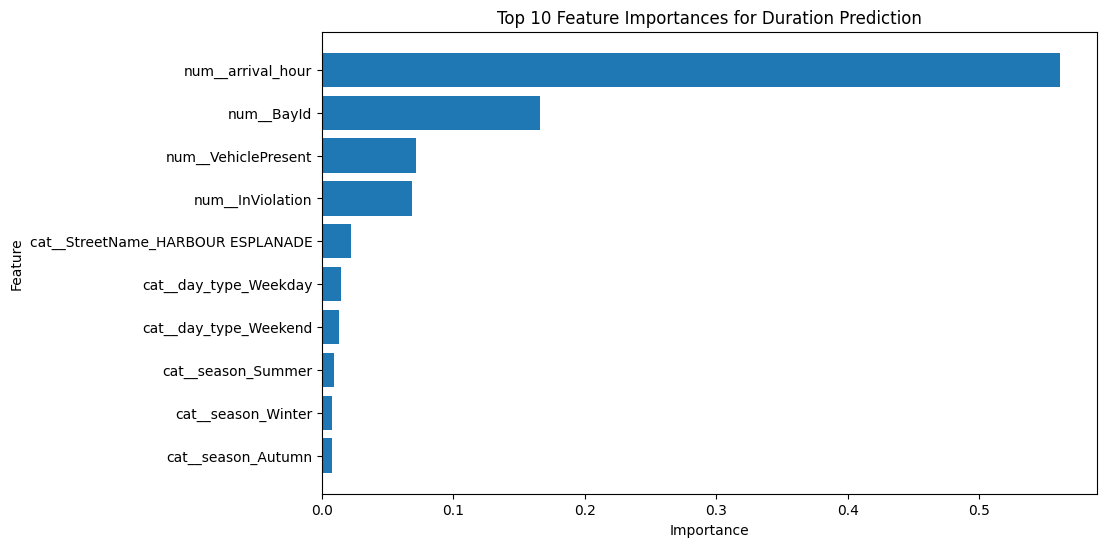

In [ ]:
plt.figure(figsize=(10, 6))
top10 = feat_imp_df.head(10).sort_values("importance")
plt.barh(top10["feature"], top10["importance"])
plt.title("Top 10 Feature Importances for Duration Prediction")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [ ]:
# Random Forest feature importance highlights which variables carry the strongest predictive signal for parking duration across temporal, operational, and street-level dimensions.

In [ ]:
##linear regression coefficient

In [ ]:
# Linear regression coefficients provide an interpretable baseline for understanding the directional effect of explanatory variables on parking duration.

import numpy as np

lr_fitted_model = lr_model.named_steps["model"]
lr_preprocessor = lr_model.named_steps["preprocessor"]

lr_feature_names = lr_preprocessor.get_feature_names_out()
lr_coefficients = lr_fitted_model.coef_

coef_df = pd.DataFrame({
    "feature": lr_feature_names,
    "coefficient": lr_coefficients
}).sort_values("coefficient", ascending=False)

print("Top positive coefficients:")
print(coef_df.head(15))

print("\nTop negative coefficients:")
print(coef_df.tail(15))

Top positive coefficients:
                              feature  coefficient
2                    num__InViolation    75.419941
23  cat__StreetName_CUMBERLAND STREET    31.906418
21       cat__StreetName_BRENTANI WAY    26.435696
25     cat__StreetName_FISHPLATE LANE    20.028251
15                 cat__season_Summer     8.470922
12              cat__day_type_Weekend     8.392808
7             cat__day_of_week_Sunday     7.156923
27  cat__StreetName_HARBOUR ESPLANADE     4.237639
33   cat__StreetName_NAVIGATION DRIVE     2.533389
13                 cat__season_Autumn     1.295978
6           cat__day_of_week_Saturday     1.235886
5             cat__day_of_week_Monday     0.627200
29     cat__StreetName_KARLSRUHE LANE     0.086742
1                          num__BayId     0.001754
28        cat__StreetName_IMPORT LANE    -0.004224

Top negative coefficients:
                               feature  coefficient
4              cat__day_of_week_Friday    -2.009310
10          cat__day_of_w

   k  silhouette_score
0  2          0.600920
1  3          0.418425
2  4          0.434222
3  5          0.490215
4  6          0.504575
         mean_occupancy  mean_duration  violation_rate  total_events  \
cluster                                                                
0              0.527433      43.813653        0.037827  43623.458333   
1              1.000000     211.000000        0.500000      2.000000   

         peak_hour_occupancy  
cluster                       
0                   0.527433  
1                   1.000000  


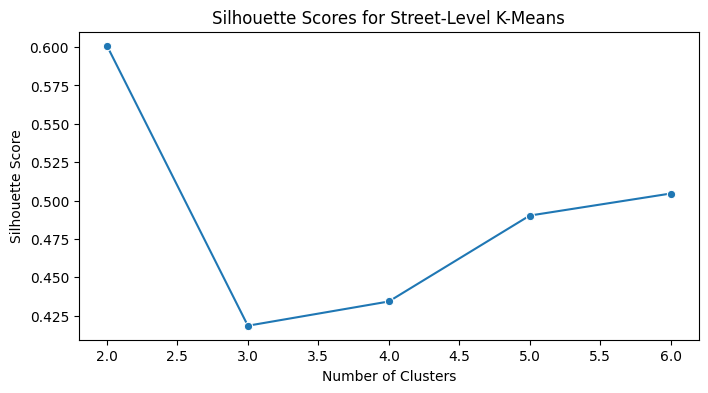

In [ ]:
# K-means clustering is used to identify recurring street-level parking typologies based on operational behavior.

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import seaborn as sns
import matplotlib.pyplot as plt

street_cluster_df = docklands_df.groupby("StreetName").agg(
    mean_occupancy=("VehiclePresent", "mean"),
    mean_duration=("DurationMinutes", "mean"),
    violation_rate=("InViolation", "mean"),
    total_events=("BayId", "count"),
    peak_hour_occupancy=("VehiclePresent", lambda x: x.mean())
).reset_index()

cluster_features = ["mean_occupancy", "mean_duration", "violation_rate", "total_events", "peak_hour_occupancy"]

scaler = StandardScaler()
X_cluster = scaler.fit_transform(street_cluster_df[cluster_features])

silhouette_results = []
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_cluster)
    score = silhouette_score(X_cluster, labels)
    silhouette_results.append((k, score))

silhouette_df = pd.DataFrame(silhouette_results, columns=["k", "silhouette_score"])
print(silhouette_df)

best_k = silhouette_df.sort_values("silhouette_score", ascending=False).iloc[0]["k"]
best_k = int(best_k)

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
street_cluster_df["cluster"] = kmeans.fit_predict(X_cluster)

cluster_profile = street_cluster_df.groupby("cluster")[cluster_features].mean()
print(cluster_profile)

plt.figure(figsize=(8, 4))
sns.lineplot(data=silhouette_df, x="k", y="silhouette_score", marker="o")
plt.title("Silhouette Scores for Street-Level K-Means")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.show()

In [ ]:
# Cluster labels are assigned after inspecting the average profile of each street-level cluster.

cluster_labels = {
    0: "High-turnover demand streets",
    1: "Long-duration pressure streets",
    2: "Low-intensity streets",
    3: "Violation-prone streets"
}

street_cluster_df["cluster_label"] = street_cluster_df["cluster"].map(cluster_labels)
street_cluster_df[["StreetName", "cluster", "cluster_label"]].head(20)

,StreetName,cluster,cluster_label
0,AQUITANIA WAY,0,High-turnover demand streets
1,AURORA LANE,0,High-turnover demand streets
2,BATMANS HILL DRIVE,0,High-turnover demand streets
3,BOURKE STREET,0,High-turnover demand streets
4,BRENTANI WAY,0,High-turnover demand streets
5,CARAVEL LANE,0,High-turnover demand streets
6,COLLINS STREET,0,High-turnover demand streets
7,CUMBERLAND STREET,0,High-turnover demand streets
8,DOCKLANDS DRIVE,0,High-turnover demand streets
9,FISHPLATE LANE,0,High-turnover demand streets
